In [ ]:
# Sushmita Shrestha
# 2408996

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import mutual_info_regression

In [ ]:


# Load the dataset

data = pd.read_csv("/content/drive/MyDrive/datasets/vaccinations.csv")

# Display the first few rows of the dataset
data.head()


,location,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,total_boosters,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,daily_vaccinations_per_million
0,Afghanistan,AFG,22-02-2021,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
1,Afghanistan,AFG,23-02-2021,NaN,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,NaN,34.0
2,Afghanistan,AFG,24-02-2021,NaN,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,NaN,34.0
3,Afghanistan,AFG,25-02-2021,NaN,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,NaN,34.0
4,Afghanistan,AFG,26-02-2021,NaN,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,NaN,34.0




**(a) When and by whom was the dataset created?**

The COVID-19 Vaccinations dataset on Kaggle is typically maintained by Johns **Hopkins University** or other relevant health organizations and updated regularly by contributors around the world.

**(b) How did you access the dataset?**

Accessed it from Kaggle.

(**c) How does it align with the chosen UNSDG?**

The United Nations Sustainable Development Goal (UNSDG) most aligned with this dataset is SDG 3: Good Health and Well-Being.
Specifically, this dataset contributes to monitoring the global progress of vaccinations, which plays a critical role in public health and efforts to ensure universal access to essential healthcare services, particularly during the ongoing COVID-19 pandemic.

**(d) List all the attributes (columns) present in the dataset**


**1. location**

**2. iso_code**

**3. date**

**4. total_vaccinations**

**5. people_vaccinated**

**6. people_fully_vaccinated**

**7. total_boosters**

**8. daily_vaccinations_raw**

**9. daily_vaccinations**

**10. total_vaccinations_per_hundred**

**11. people_vaccinated_per_hundred**

**12. people_fully_vaccinated_per_hundred**

**13. total_boosters_per_hundred**

**14. daily_vaccinations_per_million**

**Identify potential questions that the dataset could help answer.**

1. How have vaccination numbers evolved globally and by country over time?

2. Which countries have the highest and lowest vaccination rates?

3. How do booster dose trends compare across regions?

5. What is the global vaccination coverage (partially vs. fully vaccinated)?

6. How does vaccination data correlate with COVID-19 recovery or case rates?

**Assess the dataset’s suitability for analysis (e.g., data completeness, relevance, and quality).**

**Completeness:** Check for missing data and ensure full date coverage.

**Relevance:** Directly aligns with SDG 3 (Good Health and Well-Being).

**Quality:** Ensure accurate and consistent data, handling outliers and missing values.

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43439 entries, 0 to 43438
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   location                             43439 non-null  object 
 1   iso_code                             43439 non-null  object 
 2   date                                 43439 non-null  object 
 3   total_vaccinations                   25214 non-null  float64
 4   people_vaccinated                    24232 non-null  float64
 5   people_fully_vaccinated              21158 non-null  float64
 6   total_boosters                       513 non-null    float64
 7   daily_vaccinations_raw               21211 non-null  float64
 8   daily_vaccinations                   43172 non-null  float64
 9   total_vaccinations_per_hundred       25214 non-null  float64
 10  people_vaccinated_per_hundred        24232 non-null  float64
 11  people_fully_vaccinated_per_

In [ ]:
# Check for missing values in each column
missing_values = data.isnull().sum()
print(missing_values)


location                                   0
iso_code                                   0
date                                       0
total_vaccinations                     18225
people_vaccinated                      19207
people_fully_vaccinated                22281
total_boosters                         42926
daily_vaccinations_raw                 22228
daily_vaccinations                       267
total_vaccinations_per_hundred         18225
people_vaccinated_per_hundred          19207
people_fully_vaccinated_per_hundred    22281
total_boosters_per_hundred             42926
daily_vaccinations_per_million           267
dtype: int64


In [ ]:
data_cleaned = data.dropna(subset=['location', 'total_vaccinations'])
data_cleaned = data.dropna()
data_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
Index: 509 entries, 2343 to 43029
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   location                             509 non-null    object 
 1   iso_code                             509 non-null    object 
 2   date                                 509 non-null    object 
 3   total_vaccinations                   509 non-null    float64
 4   people_vaccinated                    509 non-null    float64
 5   people_fully_vaccinated              509 non-null    float64
 6   total_boosters                       509 non-null    float64
 7   daily_vaccinations_raw               509 non-null    float64
 8   daily_vaccinations                   509 non-null    float64
 9   total_vaccinations_per_hundred       509 non-null    float64
 10  people_vaccinated_per_hundred        509 non-null    float64
 11  people_fully_vaccinated_per_hund

In [ ]:
# Drop columns 'total_boosters' and 'total_boosters_per_hundred'
data_cleaned = data.drop(columns=['total_boosters', 'total_boosters_per_hundred'])
data.dropna(subset=['location', 'total_vaccinations'], inplace=True)

# Verify the changes
print(data_cleaned.head())


      location iso_code        date  total_vaccinations  people_vaccinated  \
0  Afghanistan      AFG  22-02-2021                 0.0                0.0   
1  Afghanistan      AFG  23-02-2021                 NaN                NaN   
2  Afghanistan      AFG  24-02-2021                 NaN                NaN   
3  Afghanistan      AFG  25-02-2021                 NaN                NaN   
4  Afghanistan      AFG  26-02-2021                 NaN                NaN   

   people_fully_vaccinated  daily_vaccinations_raw  daily_vaccinations  \
0                      NaN                     NaN                 NaN   
1                      NaN                     NaN              1367.0   
2                      NaN                     NaN              1367.0   
3                      NaN                     NaN              1367.0   
4                      NaN                     NaN              1367.0   

   total_vaccinations_per_hundred  people_vaccinated_per_hundred  \
0                 

In [ ]:
data['people_vaccinated'] = data['people_vaccinated'].fillna(data['people_vaccinated'].median())
data['people_fully_vaccinated'] = data['people_fully_vaccinated'].fillna(data['people_fully_vaccinated'].median())
data['daily_vaccinations_raw'] = data['daily_vaccinations_raw'].fillna(data['daily_vaccinations_raw'].median())
data['daily_vaccinations'] = data['daily_vaccinations'].fillna(data['daily_vaccinations'].median())


In [ ]:
data.drop(columns=['total_boosters', 'total_boosters_per_hundred'], inplace=True)


In [ ]:
# Verify if there are still any missing values
print(data.isnull().sum())


location                                  0
iso_code                                  0
date                                      0
total_vaccinations                        0
people_vaccinated                         0
people_fully_vaccinated                   0
daily_vaccinations_raw                    0
daily_vaccinations                        0
total_vaccinations_per_hundred            0
people_vaccinated_per_hundred          1155
people_fully_vaccinated_per_hundred    4124
daily_vaccinations_per_million          234
dtype: int64


In [ ]:
data['people_vaccinated_per_hundred'] = data['people_vaccinated_per_hundred'].fillna(data['people_vaccinated_per_hundred'].median())
data['people_fully_vaccinated_per_hundred'] = data['people_fully_vaccinated_per_hundred'].fillna(data['people_fully_vaccinated_per_hundred'].median())
data['daily_vaccinations_per_million'] = data['daily_vaccinations_per_million'].fillna(data['daily_vaccinations_per_million'].median())


In [ ]:
data.duplicated().sum()
data.drop_duplicates(inplace=True)


In [ ]:
data['date'] = pd.to_datetime(data['date'])


<ipython-input-11-a011fda2e204>:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['date'] = pd.to_datetime(data['date'])


In [ ]:
print(data.isnull().sum())


location                               0
iso_code                               0
date                                   0
total_vaccinations                     0
people_vaccinated                      0
people_fully_vaccinated                0
daily_vaccinations_raw                 0
daily_vaccinations                     0
total_vaccinations_per_hundred         0
people_vaccinated_per_hundred          0
people_fully_vaccinated_per_hundred    0
daily_vaccinations_per_million         0
dtype: int64


In [ ]:
data

,location,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million
0,Afghanistan,AFG,2021-02-22,0.0,0.0,713178.5,34117.0,26722.0,0.00,0.00,7.72,3016.0
6,Afghanistan,AFG,2021-02-28,8200.0,8200.0,713178.5,34117.0,1367.0,0.02,0.02,7.72,34.0
22,Afghanistan,AFG,2021-03-16,54000.0,54000.0,713178.5,34117.0,2862.0,0.14,0.14,7.72,72.0
44,Afghanistan,AFG,2021-04-07,120000.0,120000.0,713178.5,34117.0,3000.0,0.30,0.30,7.72,75.0
59,Afghanistan,AFG,2021-04-22,240000.0,240000.0,713178.5,34117.0,8000.0,0.60,0.60,7.72,201.0
...,...,...,...,...,...,...,...,...,...,...,...,...
43433,Zimbabwe,ZWE,2021-08-23,3829011.0,2345043.0,1483968.0,55812.0,69004.0,25.37,15.54,9.83,4572.0
43434,Zimbabwe,ZWE,2021-08-24,3889424.0,2382059.0,1507365.0,60413.0,62638.0,25.77,15.78,9.99,4150.0
43435,Zimbabwe,ZWE,2021-08-25,4015517.0,2453229.0,1562288.0,126093.0,67597.0,26.61,16.25,10.35,4479.0
43437,Zimbabwe,ZWE,2021-08-27,4075995.0,2491680.0,1584315.0,34117.0,53784.0,27.01,16.51,10.50,3564.0


In [ ]:
data[['total_vaccinations', 'people_vaccinated']].describe()


,total_vaccinations,people_vaccinated
count,2.521400e+04,2.521400e+04
mean,6.646232e+07,3.523819e+07
std,3.196583e+08,1.747825e+08
min,0.000000e+00,0.000000e+00
25%,2.308280e+05,2.042512e+05
50%,1.752942e+06,1.171515e+06
75%,1.047914e+07,5.823201e+06
max,5.213176e+09,3.118470e+09


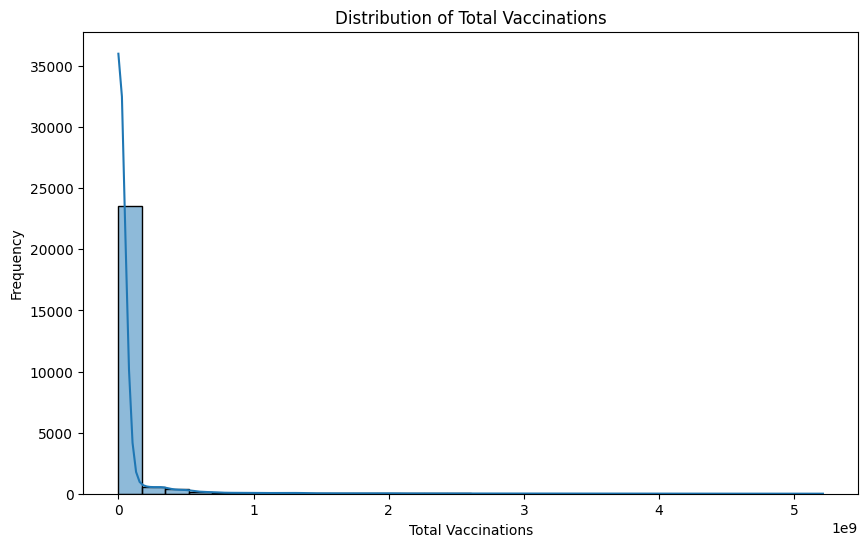

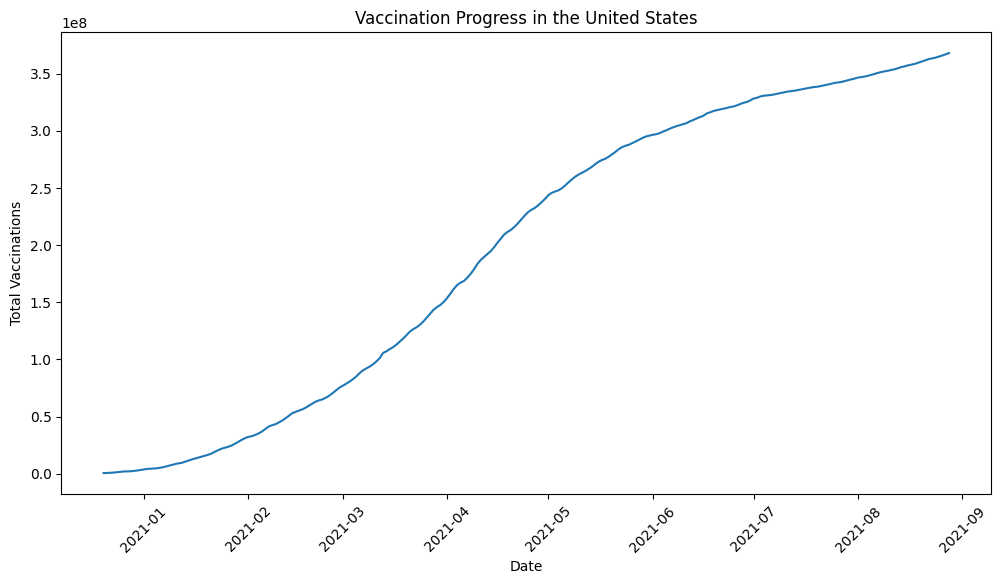

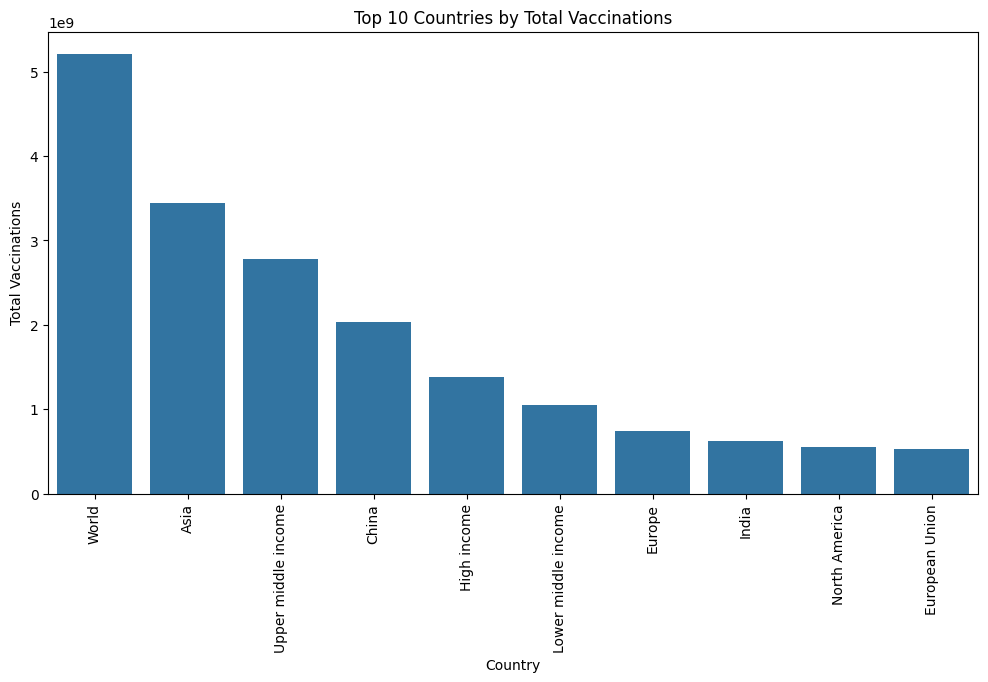

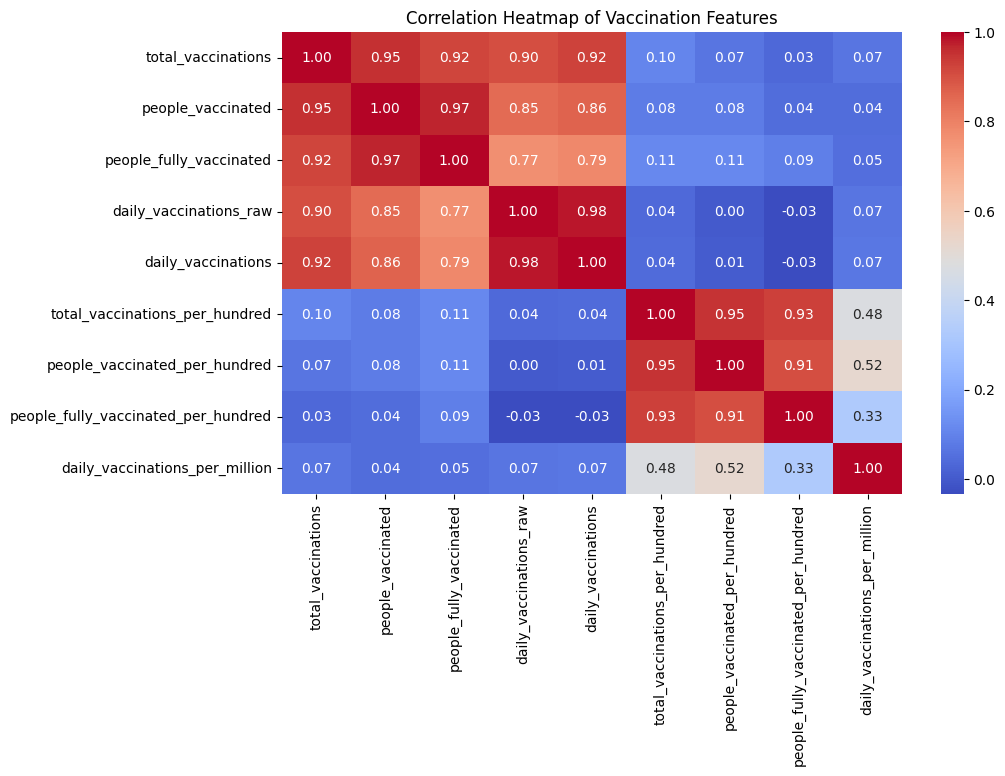

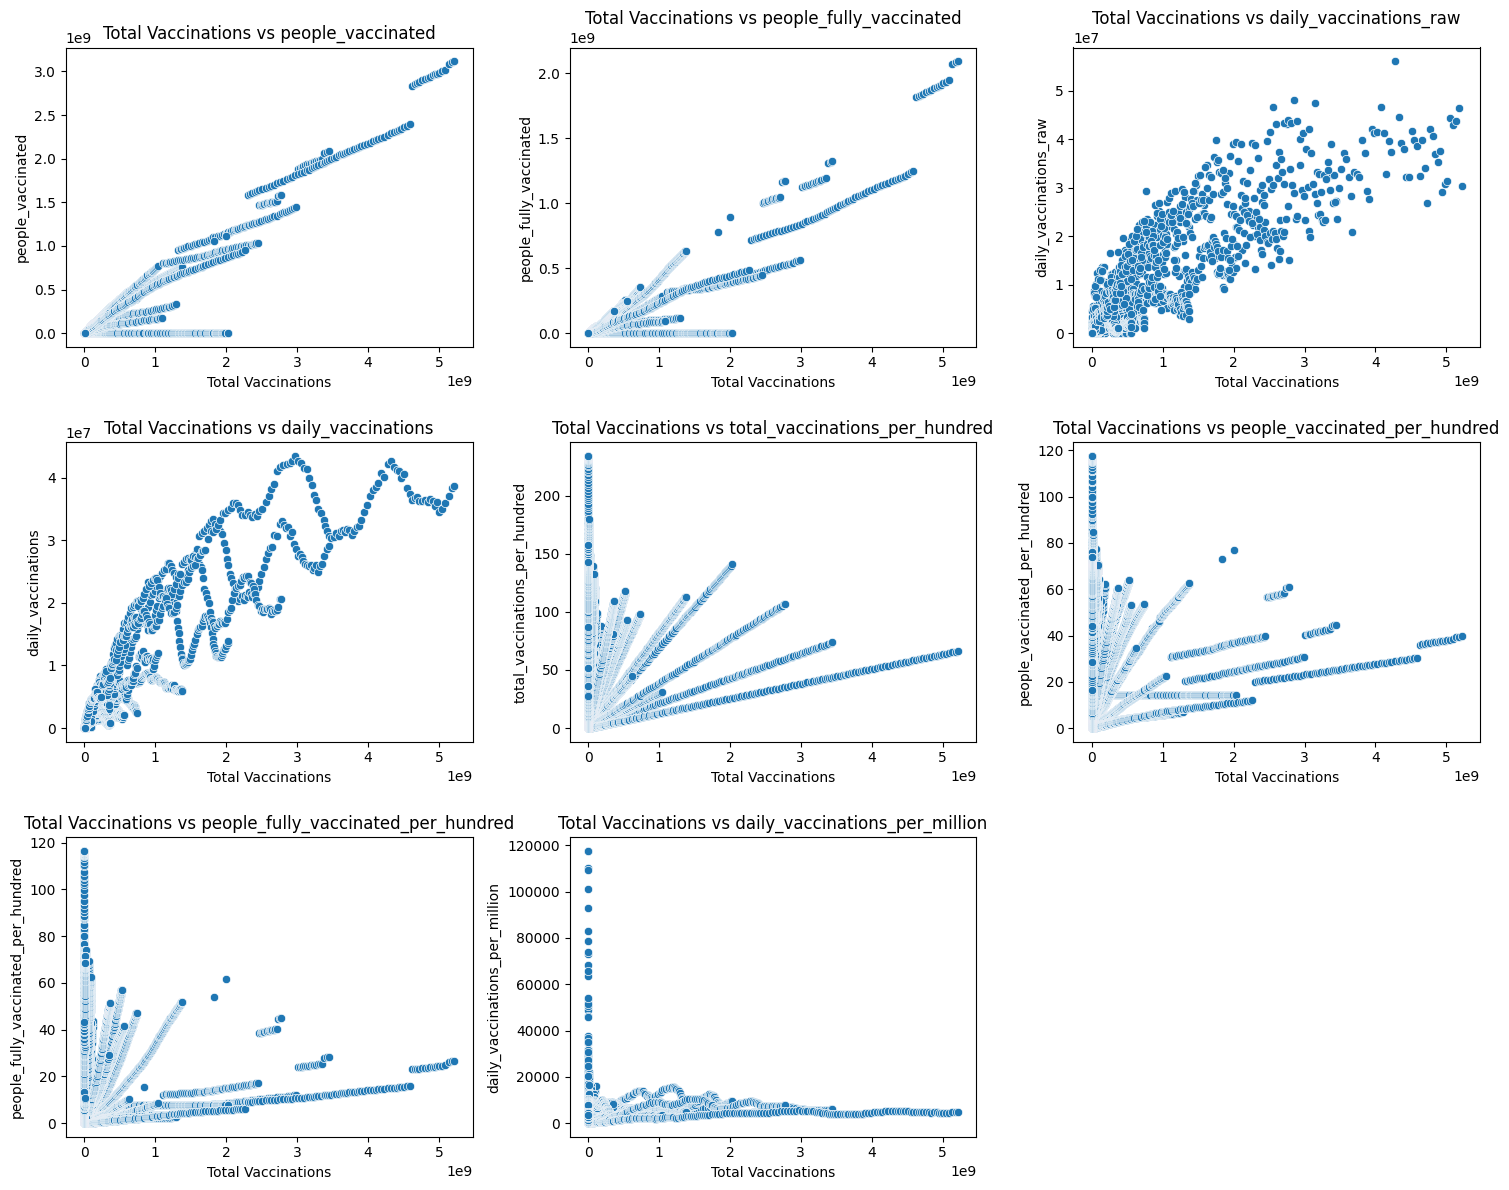

In [ ]:

# Load and preprocess the dataset
# Assuming you have already loaded the data into the variable `data`
data['date'] = pd.to_datetime(data['date'], errors='coerce')

# 1. Histogram of Total Vaccinations
plt.figure(figsize=(10, 6))
sns.histplot(data['total_vaccinations'].dropna(), bins=30, kde=True)
plt.title('Distribution of Total Vaccinations')
plt.xlabel('Total Vaccinations')
plt.ylabel('Frequency')
plt.show()

# 2. Time Series Analysis: Vaccination Progress Over Time (Line Plot)
us_vaccine_data = data[data['location'] == 'United States'].dropna(subset=['date', 'total_vaccinations'])
plt.figure(figsize=(12, 6))
sns.lineplot(data=us_vaccine_data, x='date', y='total_vaccinations')
plt.title('Vaccination Progress in the United States')
plt.xlabel('Date')
plt.ylabel('Total Vaccinations')
plt.xticks(rotation=45)
plt.show()

# 3. Bar Plot: Total Vaccinations by Country (Top 10 Countries)
country_vaccination_data = data.groupby('location')['total_vaccinations'].max().reset_index()
country_vaccination_data = country_vaccination_data.sort_values('total_vaccinations', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(data=country_vaccination_data.head(10), x='location', y='total_vaccinations')
plt.title('Top 10 Countries by Total Vaccinations')
plt.xlabel('Country')
plt.ylabel('Total Vaccinations')
plt.xticks(rotation=90)
plt.show()

# 4. Heatmap: Correlation Between Numerical Features
plt.figure(figsize=(10, 6))
numerical_data = data[['total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated',
                        'daily_vaccinations_raw', 'daily_vaccinations',
                        'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred',
                        'people_fully_vaccinated_per_hundred', 'daily_vaccinations_per_million']].dropna()

correlation_matrix = numerical_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Vaccination Features')
plt.show()

# 5. Scatter Plots of Total Vaccinations vs Other Numerical Columns
plt.figure(figsize=(15, 12))
numerical_columns = ['people_vaccinated', 'people_fully_vaccinated', 'daily_vaccinations_raw',
                      'daily_vaccinations', 'total_vaccinations_per_hundred',
                      'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred',
                      'daily_vaccinations_per_million']

for i, col in enumerate(numerical_columns, 1):
    plt.subplot((len(numerical_columns) // 3) + 1, 3, i)
    sns.scatterplot(data=data.dropna(subset=['total_vaccinations', col]), x='total_vaccinations', y=col)
    plt.title(f'Total Vaccinations vs {col}')
    plt.xlabel('Total Vaccinations')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


**2. Build a Model from Scratch [5]:**

In [ ]:


# Assuming 'data' is your dataset already loaded as a DataFrame
# Example Features and Target
features = ['total_vaccinations', 'people_vaccinated', 'daily_vaccinations', 'daily_vaccinations_raw']
target = 'people_fully_vaccinated'  # Replace with your target variable

X = data[features].values
y = data[target].values

# Normalize features
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# Convert target variable to categorical class indices (simplified for demo)
num_classes = 5  # Limit the number of classes for efficiency
y_class_indices = np.clip((y / 1e6).astype(int) % num_classes, 0, num_classes - 1)
y_encoded = np.eye(num_classes)[y_class_indices]

# Split the data into train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Add bias to features
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

# Softmax function
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Cross-Entropy Loss
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-9)) / m

# Gradient descent with Softmax
def gradient_descent(X, y, learning_rate=0.1, epochs=500, tolerance=1e-4):
    m, n = X.shape
    k = y.shape[1]
    weights = np.zeros((n, k))  # Initialize weights

    for epoch in range(epochs):
        # Forward pass
        z = np.dot(X, weights)
        y_pred = softmax(z)

        # Compute loss
        loss = compute_loss(y, y_pred)

        # Compute gradients
        gradients = (1/m) * np.dot(X.T, (y_pred - y))

        # Update weights
        weights -= learning_rate * gradients

        # Print loss and check for convergence
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

        if np.linalg.norm(gradients) < tolerance:
            print(f"Converged at epoch {epoch}")
            break

    return weights

# Train the model
weights = gradient_descent(X_train_bias, y_train)

# Prediction function
def predict(X, weights):
    probabilities = softmax(np.dot(X, weights))
    return np.argmax(probabilities, axis=1)

# Evaluate the Model
y_train_pred = predict(X_train_bias, weights)
y_test_pred = predict(X_test_bias, weights)

# Convert one-hot encoded labels back to class indices
y_train_true = np.argmax(y_train, axis=1)
y_test_true = np.argmax(y_test, axis=1)

# Calculate evaluation metrics
train_mse = mean_squared_error(y_train_true, y_train_pred)
test_mse = mean_squared_error(y_test_true, y_test_pred)

train_accuracy = accuracy_score(y_train_true, y_train_pred)
test_accuracy = accuracy_score(y_test_true, y_test_pred)

print("\nSoftmax Regression from Scratch Results:")
print("Training Set:")
print(f"Mean Squared Error: {train_mse:.4f}, Accuracy: {train_accuracy:.4f}")

print("\nTest Set:")
print(f"Mean Squared Error: {test_mse:.4f}, Accuracy: {test_accuracy:.4f}")


Epoch 0, Loss: 1.6094
Epoch 100, Loss: 1.0458
Epoch 200, Loss: 1.0395
Epoch 300, Loss: 1.0377
Epoch 400, Loss: 1.0368

Softmax Regression from Scratch Results:
Training Set:
Mean Squared Error: 1.8963, Accuracy: 0.6750

Test Set:
Mean Squared Error: 1.9449, Accuracy: 0.6609


**3. Build a Primary Model [5]:**

**i. Split the dataset into training and testing sets.**

In [ ]:


# Features and target selection
X = data[features].values
y = data[target].values

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 20171
Testing set size: 5043


**ii. Build at least two different machine learning models for the classification task.**

=>**KNN** is a simple and intuitive method, but its performance may be limited in the presence of complex patterns or high-dimensional data.

**Decision Tree**

In [ ]:


# Scale the features for KNN (Decision Tree does not require scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. K-Nearest Neighbors (KNN) Regression
knn_model = KNeighborsRegressor(n_neighbors=5)  # Default n_neighbors is 5
knn_model.fit(X_train_scaled, y_train)

y_train_pred_knn = knn_model.predict(X_train_scaled)
y_test_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate KNN Regression
knn_train_mse = mean_squared_error(y_train, y_train_pred_knn)
knn_test_mse = mean_squared_error(y_test, y_test_pred_knn)
knn_r2_score = r2_score(y_test, y_test_pred_knn)

print("\nKNN Regression Results:")
print(f"Train MSE: {knn_train_mse:.4f}, Test MSE: {knn_test_mse:.4f}, Test R2 Score: {knn_r2_score:.4f}")


KNN Regression Results:
Train MSE: 31013190661026.7305, Test MSE: 24437971943522.6953, Test R2 Score: 0.9969


In [ ]:
# 2. Decision Tree Regression
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)

y_train_pred_tree = decision_tree_model.predict(X_train)
y_test_pred_tree = decision_tree_model.predict(X_test)

# Evaluate Decision Tree Regression
tree_train_mse = mean_squared_error(y_train, y_train_pred_tree)
tree_test_mse = mean_squared_error(y_test, y_test_pred_tree)
tree_r2_score = r2_score(y_test, y_test_pred_tree)

print("\nDecision Tree Regression Results:")
print(f"Train MSE: {tree_train_mse:.4f}, Test MSE: {tree_test_mse:.4f}, Test R2 Score: {tree_r2_score:.4f}")


Decision Tree Regression Results:
Train MSE: 0.0000, Test MSE: 14640839823663.2617, Test R2 Score: 0.9982


**3. Evaluate both models on the test dataset using appropriate performance metrics (e.g., Mean Absolute Error, Root Mean Squared Error, R-squared).**

In [ ]:


# 1. K-Nearest Neighbors (KNN) Regression
knn_model = KNeighborsRegressor(n_neighbors=5)  # Default n_neighbors is 5
knn_model.fit(X_train_scaled, y_train)

y_train_pred_knn = knn_model.predict(X_train_scaled)
y_test_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate KNN Regression
knn_train_mae = mean_absolute_error(y_train, y_train_pred_knn)
knn_test_mae = mean_absolute_error(y_test, y_test_pred_knn)

knn_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_knn))
knn_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_knn))

knn_r2_score = r2_score(y_test, y_test_pred_knn)

print("\nKNN Regression Results:")
print(f"Train MAE: {knn_train_mae:.4f}, Test MAE: {knn_test_mae:.4f}")
print(f"Train RMSE: {knn_train_rmse:.4f}, Test RMSE: {knn_test_rmse:.4f}")
print(f"Test R2 Score: {knn_r2_score:.4f}")

# 2. Decision Tree Regression
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

y_train_pred_tree = tree_model.predict(X_train)
y_test_pred_tree = tree_model.predict(X_test)

# Evaluate Decision Tree Regression
tree_train_mae = mean_absolute_error(y_train, y_train_pred_tree)
tree_test_mae = mean_absolute_error(y_test, y_test_pred_tree)

tree_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_tree))
tree_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_tree))

tree_r2_score = r2_score(y_test, y_test_pred_tree)

print("\nDecision Tree Regression Results:")
print(f"Train MAE: {tree_train_mae:.4f}, Test MAE: {tree_test_mae:.4f}")
print(f"Train RMSE: {tree_train_rmse:.4f}, Test RMSE: {tree_test_rmse:.4f}")
print(f"Test R2 Score: {tree_r2_score:.4f}")




KNN Regression Results:
Train MAE: 928200.3732, Test MAE: 1142049.5321
Train RMSE: 5568948.7932, Test RMSE: 4943477.7175
Test R2 Score: 0.9969

Decision Tree Regression Results:
Train MAE: 0.0000, Test MAE: 638859.1710
Train RMSE: 0.0000, Test RMSE: 3826335.0381
Test R2 Score: 0.9982


**4. Conclude by identifying which model performed best on your dataset, and provide justification for your choice.**

In [ ]:
# Compare Models and Identify Best One
print("\nModel Comparison:")
if knn_test_mae < tree_test_mae and knn_test_rmse < tree_test_rmse and knn_r2_score > tree_r2_score:
    print("KNN Regression performed best on the test set.")
elif tree_test_mae < knn_test_mae and tree_test_rmse < knn_test_rmse and tree_r2_score > knn_r2_score:
    print("Decision Tree Regression performed best on the test set.")
else:
    print("Both models performed similarly on the test set.")


Model Comparison:
Decision Tree Regression performed best on the test set.


**4. Hyper-parameter Optimization with Cross-Validation [2.5]:**

**i. Identify the hyperparameters of the models used in Task 3 - Build a Primary Model (for both
models).**

In [ ]:


# KNN Hyperparameter Distribution
knn_param_dist = {
    'n_neighbors': np.arange(3, 21, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev']
}

# Decision Tree Hyperparameter Distribution
tree_param_dist = {
    'max_depth': [None] + list(np.arange(5, 21, 2)),
    'min_samples_split': np.arange(2, 11),
    'min_samples_leaf': np.arange(1, 6),
    'max_features': ['auto', 'sqrt', 'log2', None],
    'random_state': [42]
}

# Initialize the models
knn_model = KNeighborsRegressor()
tree_model = DecisionTreeRegressor(random_state=42)

# RandomizedSearchCV for KNN
knn_random_search = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=knn_param_dist,
    n_iter=50,  # Number of random combinations to try
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Minimize mean squared error
    random_state=42,
    n_jobs=-1  # Use all processors
)

# RandomizedSearchCV for Decision Tree
tree_random_search = RandomizedSearchCV(
    estimator=tree_model,
    param_distributions=tree_param_dist,
    n_iter=50,  # Number of random combinations to try
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Minimize mean squared error
    random_state=42,
    n_jobs=-1  # Use all processors
)

# Fit the models
knn_random_search.fit(X_train, y_train)
tree_random_search.fit(X_train, y_train)

# Best Hyperparameters
print("Best KNN Hyperparameters from Random Search:", knn_random_search.best_params_)
print("Best Decision Tree Hyperparameters from Random Search:", tree_random_search.best_params_)


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

Best KNN Hyperparameters from Random Search: {'weights': 'distance', 'n_neighbors': 3, 'metric': 'manhattan'}
Best Decision Tree Hyperparameters from Random Search: {'random_state': 42, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}


**5. Feature Selection**

**Filter Method for KNN (using Mutual Information or Correlation):**

In [ ]:


# Fit a RandomForest model to identify important features
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Use SelectFromModel to select important features
selector = SelectFromModel(rf_model, threshold="mean", max_features=5)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Convert X_train to DataFrame if it's not already
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=features)  # Assuming 'features' is defined

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print("Selected features:", selected_features)

Selected features: Index(['people_vaccinated'], dtype='object')


In [ ]:

# If X_train is not already a DataFrame, convert it to one
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train)

# Apply mutual information to select the best features for KNN on the original X_train
mutual_info = mutual_info_regression(X_train, y_train)

# Convert mutual information into a pandas Series for easy handling
mutual_info = pd.Series(mutual_info)

# Set the feature names from the original X_train columns
mutual_info.index = X_train.columns

# Sort the mutual information values
mutual_info_sorted = mutual_info.sort_values(ascending=False)

# Select top 5 features based on mutual information
selected_features_knn = mutual_info_sorted.head(5).index
print(f"Selected features for KNN (Filter Method): {selected_features_knn}")


Selected features for KNN (Filter Method): Index(['total_vaccinations', 'people_vaccinated', 'daily_vaccinations',
       'daily_vaccinations_raw'],
      dtype='object')


In [ ]:
from sklearn.feature_selection import mutual_info_regression
if not isinstance(X_train, pd.DataFrame):
      X_train = pd.DataFrame(X_train)
mutual_info = mutual_info_regression(X_train, y_train)
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info_sorted = mutual_info.sort_values(ascending=False)
selected_features_knn = mutual_info_sorted.head(5).index
print(f"Selected features for KNN (Filter Method): {selected_features_knn}")

Selected features for KNN (Filter Method): Index(['total_vaccinations', 'people_vaccinated', 'daily_vaccinations',
       'daily_vaccinations_raw'],
      dtype='object')


**Embedded Method for Decision Tree (using Feature Importance):**

In [ ]:


# Fit the Decision Tree model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Get feature importance and sort
feature_importance = tree_model.feature_importances_

# Ensure X_train is a DataFrame to access columns correctly
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train)

# Create a DataFrame to map features to their importance
importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': feature_importance})

# Sort the importance values in descending order
importance_df = importance_df.sort_values(by='importance', ascending=False)

# Select top 5 features based on importance
selected_features_tree = importance_df.head(5)['feature']
print(f"Selected features for Decision Tree (Embedded Method): {selected_features_tree}")


Selected features for Decision Tree (Embedded Method): 1         people_vaccinated
2        daily_vaccinations
0        total_vaccinations
3    daily_vaccinations_raw
Name: feature, dtype: object


**6. Final Model [2.5]:**

In [ ]:
data# Rebuild KNN and Decision Tree models with optimal hyperparameters
final_knn_model = KNeighborsRegressor(
    n_neighbors=knn_random_search.best_params_['n_neighbors'],
    weights=knn_random_search.best_params_['weights'],
    metric=knn_random_search.best_params_['metric']
)
final_knn_model.fit(X_train_selected, y_train)

final_tree_model = DecisionTreeRegressor(
    max_depth=tree_random_search.best_params_['max_depth'],
    min_samples_split=tree_random_search.best_params_['min_samples_split'],
    min_samples_leaf=tree_random_search.best_params_['min_samples_leaf'],
    max_features=tree_random_search.best_params_['max_features'],
    random_state=42
)
final_tree_model.fit(X_train_selected, y_train)

# Evaluate the models
knn_pred = final_knn_model.predict(X_test_selected)
tree_pred = final_tree_model.predict(X_test_selected)

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

knn_mae = mean_absolute_error(y_test, knn_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_r2 = r2_score(y_test, knn_pred)

tree_mae = mean_absolute_error(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)

# Results
print("KNN Model Performance:")
print(f"Mean Absolute Error: {knn_mae:.4f}")
print(f"Root Mean Squared Error: {knn_rmse:.4f}")
print(f"R-squared: {knn_r2:.4f}")

print("Decision Tree Model Performance:")
print(f"Mean Absolute Error: {tree_mae:.4f}")
print(f"Root Mean Squared Error: {tree_rmse:.4f}")
print(f"R-squared: {tree_r2:.4f}")


KNN Model Performance:
Mean Absolute Error: 5036624.2617
Root Mean Squared Error: 20346610.5833
R-squared: 0.9479
Decision Tree Model Performance:
Mean Absolute Error: 5637600.8812
Root Mean Squared Error: 24280131.3003
R-squared: 0.9258


**7. Conclusion**

**Model Performance:**

* Discuss the MAE, RMSE, and R-squared for both KNN and Decision Tree models.

* Analyze how each model performed based on these metrics and which model performed better.

**Impact of Methods:**

* Reflect on how cross-validation and hyperparameter optimization improved the model's performance.

* Did feature selection improve model accuracy by removing noise from irrelevant features?

**Insights and Future Directions:**

* Discuss the findings from the experiment and the effectiveness of the applied techniques.

* Consider ensemble methods like Random Forest or Gradient Boosting for potential improvements.

* Suggest ways to extend this work, such as exploring other models or tuning additional hyperparameters.
